# Model

- Load preprocessed CSV data

Model:
- Esw goes into a dilated CNN
- Rth, Vth go into LSTM
- Combine outputs in Cross-Attention layer: CNN outputs quries, LSTM outputs keys and values
- Final output is Remaining Useful Life (RUL) prediction


In [1]:
import pandas as pd 
import torch
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd 
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the processed data for each device
# Since we only have data for 4 devices, we'll use devices 3-5 for training and device 2 for development/testing
device_2_data = pd.read_csv("processed-data/device_2_processed.csv").iloc[100:]
device_3_data = pd.read_csv("processed-data/device_3_processed.csv").iloc[100:]
device_4_data = pd.read_csv("processed-data/device_4_processed.csv").iloc[100:]
device_5_data = pd.read_csv("processed-data/device_5_processed.csv").iloc[100:]

# Normalize time for each device to count up from 0
device_2_data["time"] = device_2_data["timeEpoch"] - device_2_data["timeEpoch"].min()
device_3_data["time"] = device_3_data["timeEpoch"] - device_3_data["timeEpoch"].min()
device_4_data["time"] = device_4_data["timeEpoch"] - device_4_data["timeEpoch"].min()
device_5_data["time"] = device_5_data["timeEpoch"] - device_5_data["timeEpoch"].min()

# Calculate Delta Vth (baseline is first measurement after slicing)
device_2_data["Delta_Vt"] = device_2_data["Vt"] - device_2_data["Vt"].iloc[0]
device_3_data["Delta_Vt"] = device_3_data["Vt"] - device_3_data["Vt"].iloc[0]
device_4_data["Delta_Vt"] = device_4_data["Vt"] - device_4_data["Vt"].iloc[0]
device_5_data["Delta_Vt"] = device_5_data["Vt"] - device_5_data["Vt"].iloc[0]

# Normalize features to prevent activation explosion
# Compute statistics from training data
all_train = [device_3_data, device_4_data, device_5_data]
esw_mean = np.concatenate([d['Esw'].values for d in all_train]).mean()
esw_std = np.concatenate([d['Esw'].values for d in all_train]).std()
rth_mean = np.concatenate([d['Rth'].values for d in all_train]).mean()
rth_std = np.concatenate([d['Rth'].values for d in all_train]).std()
dv_mean = np.concatenate([d['Delta_Vt'].values for d in all_train]).mean()
dv_std = np.concatenate([d['Delta_Vt'].values for d in all_train]).std()

# Apply normalization to all datasets
for data in [device_2_data, device_3_data, device_4_data, device_5_data]:
    data["Esw"] = (data["Esw"] - esw_mean) / esw_std
    data["Rth"] = (data["Rth"] - rth_mean) / rth_std
    data["Delta_Vt"] = (data["Delta_Vt"] - dv_mean) / dv_std

data_train = [device_3_data, device_4_data, device_5_data]
data_dev = device_2_data

In [65]:
device_2_data.columns

Index(['timeEpoch', 'date', 'time_domain_dt', 'frequency_domain_dxAmplitude',
       'frequency_domain_dxPhase', 'Esw', 'Vt',
       'time_domain_internalTemperature', 'time_domain_packageTemperature',
       'time_domain_supplyVoltage', 'time_domain_collectorEmitterCurrent',
       'Rth', 'RUL', 'time', 'Delta_Vt'],
      dtype='object')

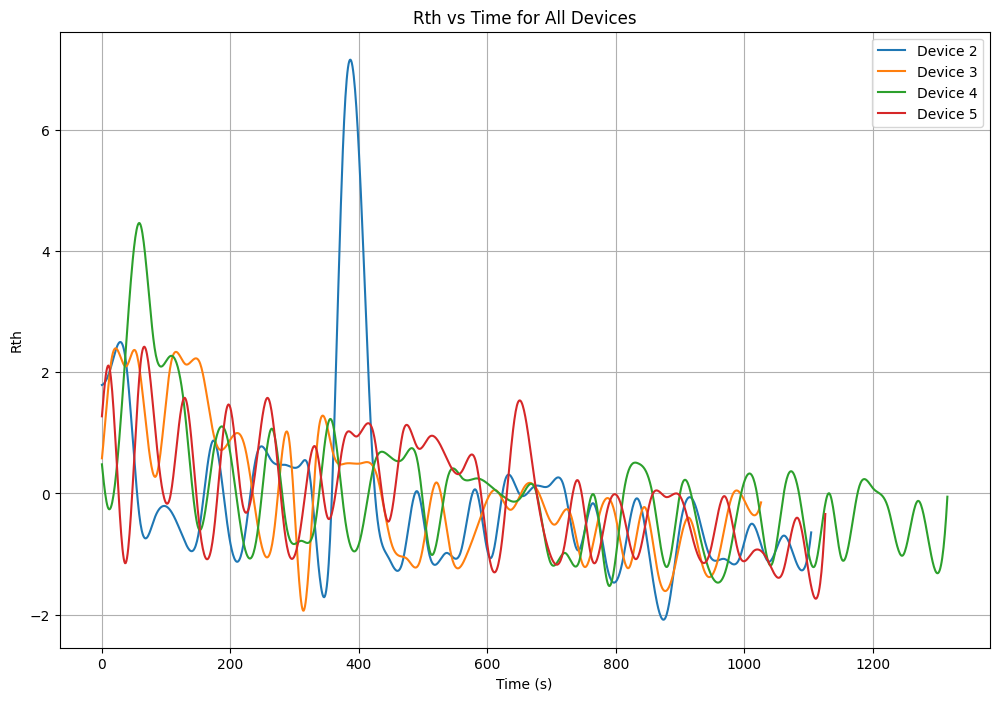

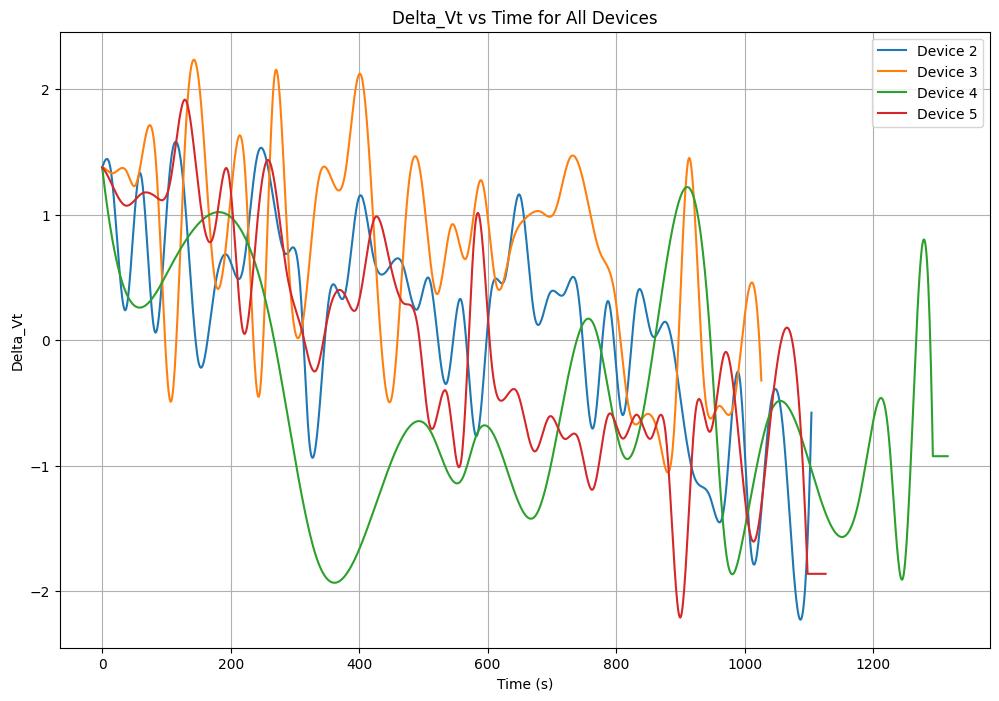

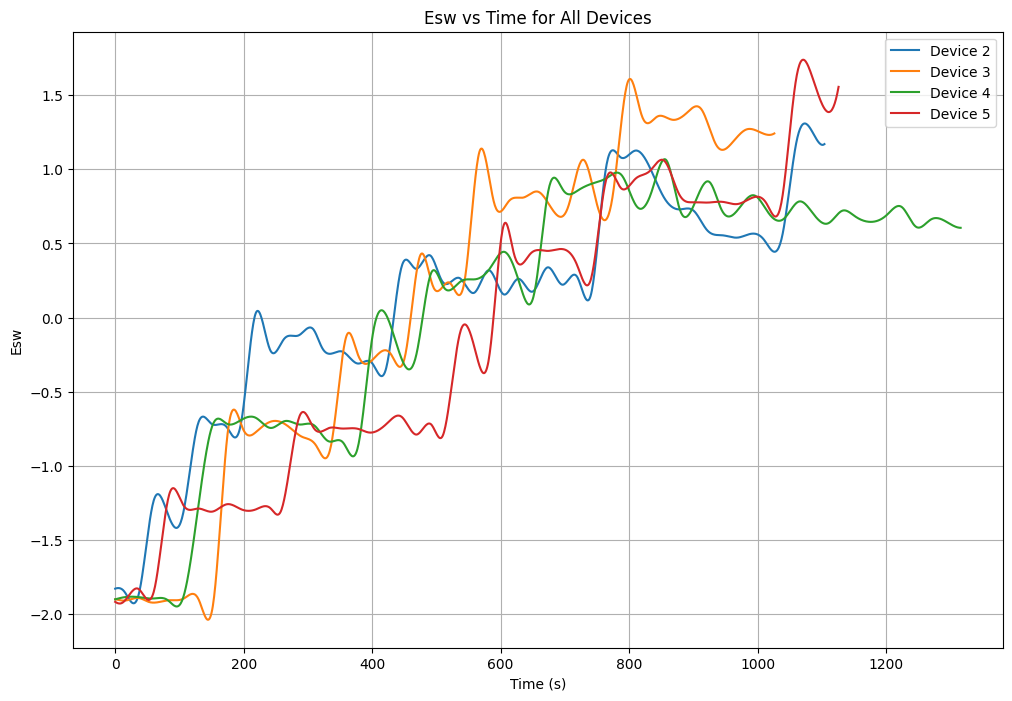

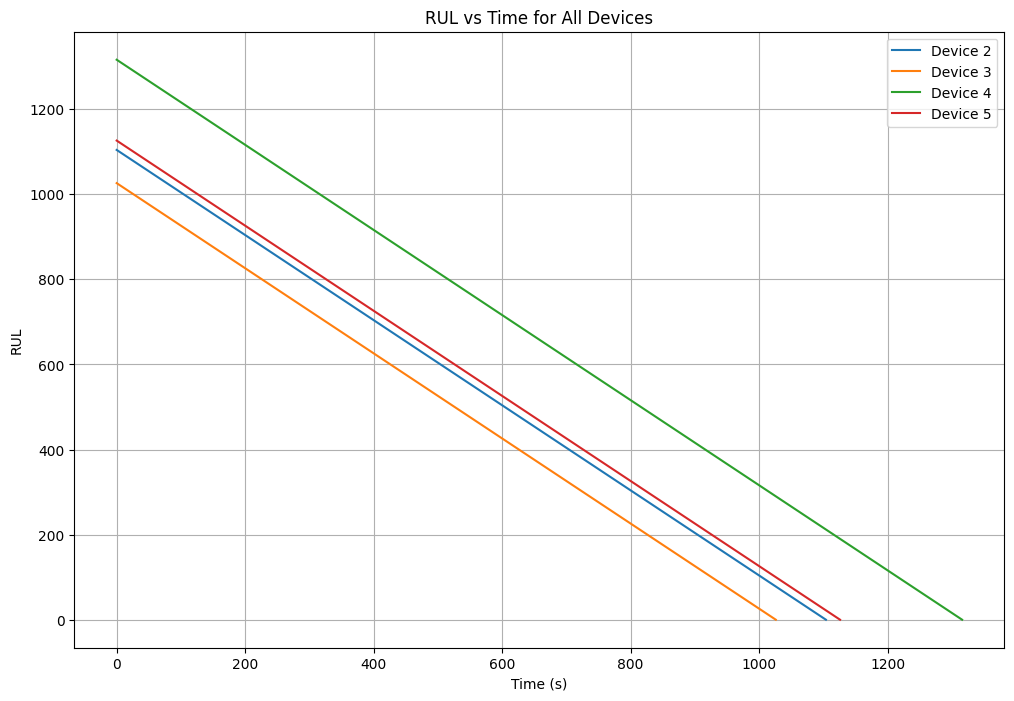

In [3]:
# Plot all features for each device
devices = [device_2_data, device_3_data, device_4_data, device_5_data]
device_names = ["Device 2", "Device 3", "Device 4", "Device 5"]

features = ['Rth', 'Delta_Vt', 'Esw', 'RUL']

# Plot eacah feature in a separate subplot for each device
for feature in features:
    plt.figure(figsize=(12, 8))
    for device, name in zip(devices, device_names):
        plt.plot(device['time'], device[feature], label=name)
    plt.title(f"{feature} vs Time for All Devices")
    plt.xlabel("Time (s)")
    plt.ylabel(feature)
    plt.legend()
    plt.grid()
    plt.show()


In [30]:
# Model definitions

rul_scale = 2000.0  # To normalize the RUL values to be bewteen 0 and 1, which Claude recommended might be a good idea...

class RULModel(torch.nn.Module):
    """ Contains a CNN fed by Esw, an LSTM fed by Rth and Vt, and a cross attention layer that combines the CNN and LSTM outputs to predict RUL. """
    def __init__(self, input_size: int, hidden_size: int, num_layers: int):
        super(RULModel, self).__init__()
        self.cnnconv1=    torch.nn.Conv1d(in_channels=1, out_channels=hidden_size, kernel_size=7, padding='same', dilation=16)
        self.cnnconv2=    torch.nn.Conv1d(in_channels=hidden_size, out_channels=hidden_size, kernel_size=5, padding='same')
        self.cnnrelu =    torch.nn.ReLU()
        self.cnnbn = torch.nn.BatchNorm1d(hidden_size)
        self.lstm = torch.nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.attention = torch.nn.MultiheadAttention(embed_dim=hidden_size, num_heads=2, batch_first=True)
        self.fc = torch.nn.Linear(hidden_size, 1)

    def forward(self, esw, rth_vt):
        # CNN branch for Esw
        # esw = esw.permute(0,2,1)  # Add channel dimension; suggested by Gemini
        # esw = esw.unsqueeze(1)  # Add channel dimension
        esw = esw.view(esw.size(0), 1, -1)  # Reshape to (1, 1, seq_len)
        rth_vt = rth_vt.view(rth_vt.size(0), -1, 2)  # Add batch dimension for LSTM

        cnn_out = self.cnnconv1(esw)
        cnn_out = self.cnnrelu(cnn_out)
        cnn_out = self.cnnconv2(cnn_out)
        cnn_out = self.cnnrelu(cnn_out)
        cnn_out = self.cnnbn(cnn_out)
        cnn_out = cnn_out.transpose(1,2)  # (batch, seq_len, hidden_size)
        
        # LSTM branch for Rth and Vt
        lstm_out, _ = self.lstm(rth_vt)
        
        # Cross attention between CNN and LSTM outputs
        attn_output, _ = self.attention(cnn_out, lstm_out, lstm_out)
        
        # Final RUL prediction using fused attention output
        rul_pred = self.fc(attn_output)  # Per-timestep predictions: (batch, seq_len, 1)
        
        return rul_pred


In [31]:
# Try to train the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def predict_rul(model, data, window_size=50):
    model.eval()
    rul_preds = []
    with torch.no_grad():
        for start_idx in range(0, len(data) - window_size, window_size):
            data_window = data.iloc[start_idx:start_idx+window_size]

            esw = torch.tensor(data_window['Esw'].values, dtype=torch.float32).unsqueeze(0).to(device)
            rth_vt = torch.tensor(data_window[['Rth', 'Delta_Vt']].values, dtype=torch.float32).unsqueeze(0).to(device)

            rul_pred = model(esw, rth_vt)
            rul_preds.append(rul_pred.item())
    
    return rul_preds

def train_model(model, data_train, data_dev, num_epochs=100, learning_rate=0.001, batch_size=100):
    mseloss = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    allloss = []

    # move things to the device:
    model.to(device)
    mseloss.to(device)
    # data_dev = data_dev.to(device)
    # data_train = [d.to(device) for d in data_train]

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for device_data in data_train:
            # window_size = np.random.randint(256, 2048)  # Random window size
            # Claude helped with trasforming my code from individual runs to batching, which speeds things up tremendously!
            # i=0
            # esw_batch = torch.stack([
            #     torch.tensor(device_data.iloc[i:i+window_size]['Esw'].values, dtype=torch.float32)
            #     for window_size in range(8, len(device_data))
            # ]).to(device)  # (batch_size, window_size)
            
            # rth_vt_batch = torch.stack([
            #     torch.tensor(device_data.iloc[i:i+window_size][['Rth', 'Delta_Vt']].values, dtype=torch.float32)
            #     for window_size in range(8, len(device_data))
            # ]).to(device)  # (batch_size, window_size, 2)
            
            # rul_batch = torch.tensor([
            #     device_data.iloc[i+window_size-1]['RUL'] / rul_scale
            #     for window_size in range(8, len(device_data))
            # ], dtype=torch.float32).to(device)  # (batch_size,)

            esw = torch.tensor(device_data['Esw'].values, dtype=torch.float32).unsqueeze(0).to(device)
            rth_vt = torch.tensor(device_data[['Rth', 'Delta_Vt']].values, dtype=torch.float32).unsqueeze(0).to(device)

            # Get rul at the end of the window
            # rul = torch.tensor(device_data_window.iloc[-1]['RUL'], dtype=torch.float32).to(device) / rul_scale  # Normalize RUL to be between 0 and 1

            optimizer.zero_grad()
            # rul_pred = model(esw_batch, rth_vt_batch)
    
            # Calculate coffin manson estimate
            # delta_T_batch = torch.tensor([
            #     device_data.iloc[i:i+window_size]['time_domain_internalTemperature'].max() -
            #     device_data.iloc[i:i+window_size]['time_domain_internalTemperature'].min()
            #     for window_size in range(8, len(device_data))
            # ], dtype=torch.float32).to(device)
            # Nf_batch = 0.05 * (delta_T_batch ** -2.5)

            rul_pred = model(esw, rth_vt)
            rul_true = torch.tensor(device_data['RUL'].values / rul_scale, dtype=torch.float32).to(device)  # (N,)
                
            loss = 0.7 * mseloss(rul_pred.squeeze(), rul_true) + 0.3 * torch.abs(rul_pred.squeeze() - rul_true).mean()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Evaluate on development set (full sequence like training)
        model.eval()
        dev_loss = 0.0
        with torch.no_grad():
            data_dev_window = data_dev

            esw_dev = torch.tensor(data_dev_window['Esw'].values, dtype=torch.float32).unsqueeze(0).to(device)
            rth_vt_dev = torch.tensor(data_dev_window[['Rth', 'Delta_Vt']].values, dtype=torch.float32).unsqueeze(0).to(device)

            # Get full RUL sequence for dev set (not just final value)
            rul_dev_full = torch.tensor(data_dev_window['RUL'].values / rul_scale, dtype=torch.float32).to(device)
            rul_pred_dev = model(esw_dev, rth_vt_dev)

            # Compute loss over full sequence like training
            dev_loss = 0.7 * mseloss(rul_pred_dev.squeeze(), rul_dev_full) + 0.3 * torch.abs(rul_pred_dev.squeeze() - rul_dev_full).mean()

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(data_train):.4f}, Dev Loss: {dev_loss:.4f}")
        allloss += [(train_loss/len(data_train), dev_loss/len(data_dev))]

    return allloss


In [32]:
# Train the model...

model = RULModel(input_size=2, hidden_size=32, num_layers=2)
loss = train_model(model, data_train, data_dev, num_epochs=100, learning_rate=0.0001, batch_size=256)

Epoch 1/100, Train Loss: 0.0861, Dev Loss: 0.0769
Epoch 2/100, Train Loss: 0.0840, Dev Loss: 0.0750
Epoch 3/100, Train Loss: 0.0820, Dev Loss: 0.0733
Epoch 4/100, Train Loss: 0.0801, Dev Loss: 0.0716
Epoch 5/100, Train Loss: 0.0784, Dev Loss: 0.0701
Epoch 6/100, Train Loss: 0.0767, Dev Loss: 0.0687
Epoch 7/100, Train Loss: 0.0752, Dev Loss: 0.0674
Epoch 8/100, Train Loss: 0.0737, Dev Loss: 0.0662
Epoch 9/100, Train Loss: 0.0724, Dev Loss: 0.0651
Epoch 10/100, Train Loss: 0.0712, Dev Loss: 0.0641
Epoch 11/100, Train Loss: 0.0700, Dev Loss: 0.0632
Epoch 12/100, Train Loss: 0.0690, Dev Loss: 0.0624
Epoch 13/100, Train Loss: 0.0681, Dev Loss: 0.0617
Epoch 14/100, Train Loss: 0.0673, Dev Loss: 0.0611
Epoch 15/100, Train Loss: 0.0666, Dev Loss: 0.0606
Epoch 16/100, Train Loss: 0.0659, Dev Loss: 0.0602
Epoch 17/100, Train Loss: 0.0654, Dev Loss: 0.0598
Epoch 18/100, Train Loss: 0.0650, Dev Loss: 0.0596
Epoch 19/100, Train Loss: 0.0646, Dev Loss: 0.0594
Epoch 20/100, Train Loss: 0.0643, Dev Lo

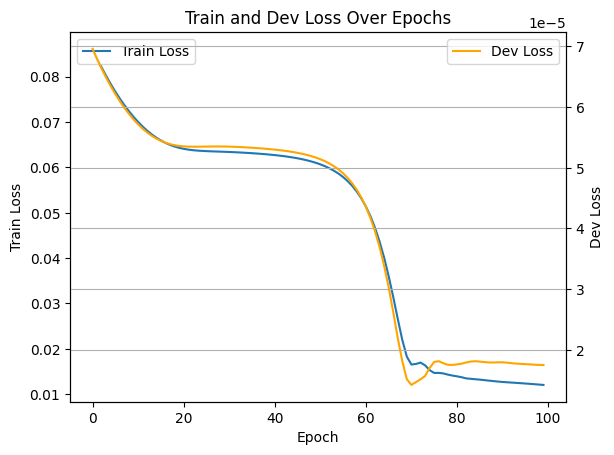

In [33]:

# plot train, dev loss on separate y-axes:
plt.title("Train and Dev Loss Over Epochs")
plt.xlabel("Epoch")
plt.plot([l[0] for l in loss], label="Train Loss")
plt.ylabel("Train Loss")
plt.legend(loc="upper left")
plt.twinx()
plt.plot([l[1].cpu() for l in loss], label="Dev Loss", color='orange')
plt.ylabel("Dev Loss")
plt.legend(loc="upper right")
plt.grid()
plt.show()

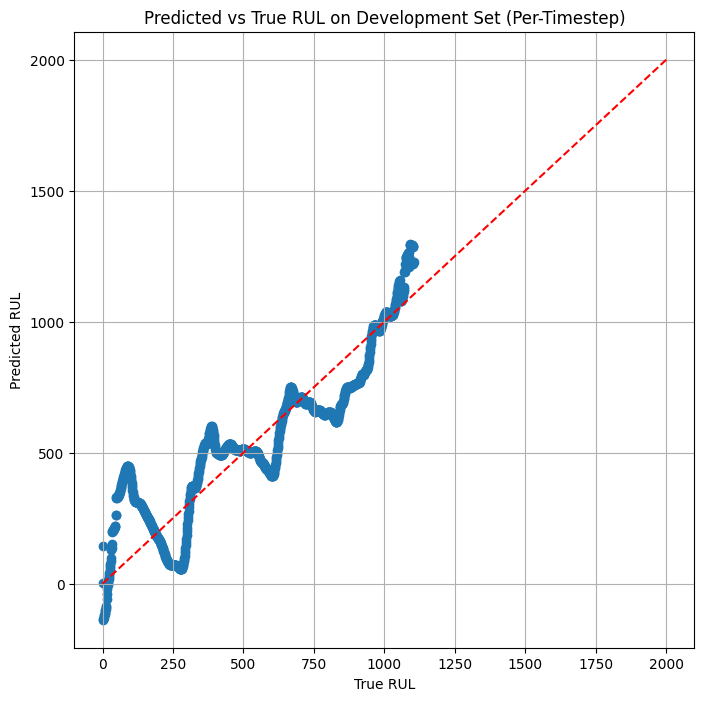

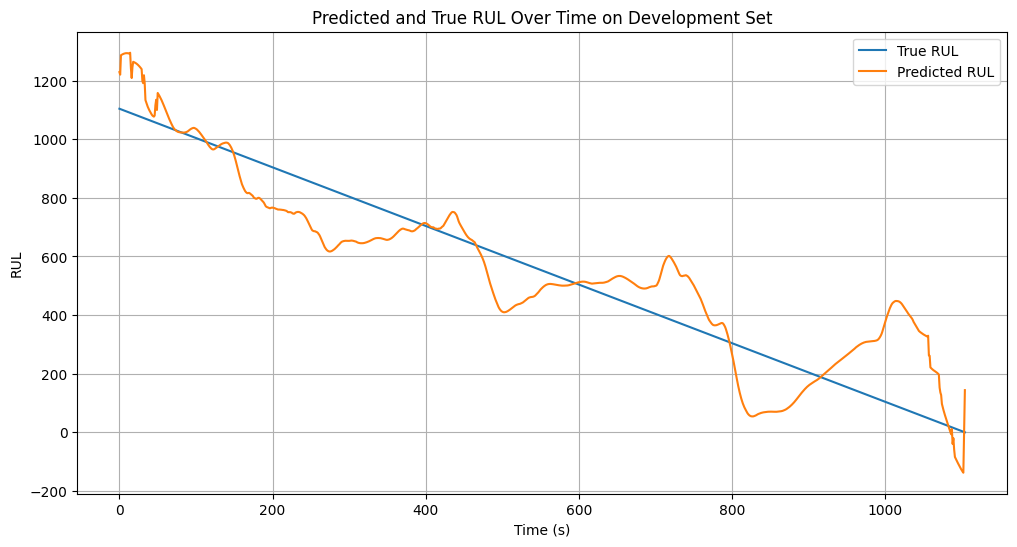

In [37]:
# Plot estimated RUL vs true RUL for the development set
# Evaluate on full sequence to get per-timestep predictions

model.eval()
with torch.no_grad():
    esw_dev = torch.tensor(data_dev['Esw'].values, dtype=torch.float32).unsqueeze(0).to(device)
    rth_vt_dev = torch.tensor(data_dev[['Rth', 'Delta_Vt']].values, dtype=torch.float32).unsqueeze(0).to(device)
    
    rul_pred_dev = model(esw_dev, rth_vt_dev)  # (1, seq_len, 1)
    rul_true_dev = data_dev['RUL'].values  # (seq_len,)
    rul_pred_values = rul_pred_dev.squeeze().cpu().numpy() * rul_scale  # (seq_len,)

# Plot - each point is a timestep
plt.figure(figsize=(8, 8))
plt.scatter(rul_true_dev, rul_pred_values)
plt.plot([0, 2000], [0, 2000], 'r--')  # Line y=x for reference
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs True RUL on Development Set (Per-Timestep)")
plt.grid()
plt.show()


# Also plot predicted and true side by side over time
plt.figure(figsize=(12, 6))
plt.plot(data_dev['time'], rul_true_dev, label="True RUL")
plt.plot(data_dev['time'], rul_pred_values, label="Predicted RUL")
plt.xlabel("Time (s)")
plt.ylabel("RUL")
plt.legend()
plt.title("Predicted and True RUL Over Time on Development Set")
plt.grid()
plt.show()